# Bước 4 – Lựa Chọn Mô Hình & Huấn Luyện (Model Selection & Training) — PHIÊN BẢN CẢI THIỆN

## Mục tiêu
Xây dựng và so sánh ít nhất **3 mô hình** cho bài toán **phân loại** (dự đoán xu hướng Lên/Xuống) và **hồi quy** (dự đoán giá đóng cửa ngày t+1).

## Cải tiến so với phiên bản trước:
1. **Feature Engineering nâng cao**: Thêm ROC, ADX, Williams %R, Stochastic Oscillator, ATR, OBV, interaction features
2. **Feature Selection**: Loại bỏ features tương quan cao (>0.95) để giảm noise
3. **Target Engineering**: Thêm ngưỡng ±0.3% cho classification (loại bỏ noise), return-based regression cho VIC
4. **Thêm models**: LightGBM (Cls + Reg), SVM (Classification)
5. **Chống Overfitting**: Tăng regularization (reg_alpha, reg_lambda), scale tất cả models, n_iter=50
6. **Hyperparameter search rộng hơn**: n_iter 20 → 50

## Mô hình sử dụng

### Bài toán Phân loại (Classification) — 5 models:
| Mô hình | Thư viện | Ghi chú |
|---------|----------|---------|
| **Logistic Regression** | sklearn | Baseline tuyến tính + L1/L2 regularization |
| **Random Forest** | sklearn | Ensemble bagging + depth limit |
| **XGBoost** | xgboost | Boosting + reg_alpha/reg_lambda |
| **LightGBM** | lightgbm | **MỚI** — Faster boosting, leaf-wise growth |
| **SVM** | sklearn | **MỚI** — Support Vector Machine + RBF kernel |

### Bài toán Hồi quy (Regression) — 4 models:
| Mô hình | Thư viện | Ghi chú |
|---------|----------|---------|
| **Random Forest Regressor** | sklearn | Ensemble bagging |
| **XGBoost Regressor** | xgboost | Boosting + regularization |
| **LightGBM Regressor** | lightgbm | **MỚI** — Leaf-wise boosting |
| **SVR** | sklearn | **MỚI** — Support Vector Regression |

## Phương pháp:
- **TimeSeriesSplit** (n_splits=5) cho cross-validation — **BẮT BUỘC** không dùng random split
- **RandomizedSearchCV** (n_iter=50) để tìm hyperparameter tối ưu
- **StandardScaler** cho TẤT CẢ models (không chỉ LR)
- Huấn luyện trên **tất cả 5 mã cổ phiếu**

## 4.1. Import thư viện

In [ ]:
import os
import pickle
import warnings
import time
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn — Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC, SVR
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

# Sklearn — Evaluation & Tuning
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             mean_squared_error, mean_absolute_error, r2_score)

# Cấu hình
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
np.random.seed(42)

# Đường dẫn
FE_DIR = os.path.join('..', 'data', 'processed', 'feature_engineered')
MODELS_DIR = os.path.join('..', 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

STOCK_SYMBOLS = ['VCB', 'FPT', 'HPG', 'VIC', 'POW']

# TimeSeriesSplit — BẮT BUỘC cho dữ liệu chuỗi thời gian
tscv = TimeSeriesSplit(n_splits=5)

print(f"TimeSeriesSplit: {tscv.n_splits} folds")
print(f"Models dir: {MODELS_DIR}")
print(f"\nLibraries:")
print(f"  scikit-learn: LogisticRegression, RandomForest, SVC/SVR")
print(f"  xgboost: XGBClassifier, XGBRegressor")
print(f"  lightgbm: LGBMClassifier, LGBMRegressor")

## 4.2. Tải dữ liệu Feature Engineered (Train)

In [11]:
# Tải dữ liệu train đã feature engineered từ Bước 3
train_datasets = {}
test_datasets = {}

for symbol in STOCK_SYMBOLS:
    train_path = os.path.join(FE_DIR, symbol, f'{symbol}_train_features.csv')
    test_path = os.path.join(FE_DIR, symbol, f'{symbol}_test_features.csv')
    
    train_df = pd.read_csv(train_path)
    train_df['time'] = pd.to_datetime(train_df['time'])
    train_datasets[symbol] = train_df
    
    test_df = pd.read_csv(test_path)
    test_df['time'] = pd.to_datetime(test_df['time'])
    test_datasets[symbol] = test_df
    
    print(f"✓ {symbol}: Train={train_df.shape}, Test={test_df.shape}")

# Xác định cột feature và target
exclude_cols = ['time', 'target_cls', 'target_reg']
feature_cols = [col for col in train_datasets['FPT'].columns if col not in exclude_cols]

print(f"\nSố features: {len(feature_cols)}")
print(f"Features: {feature_cols}")
print(f"Targets: target_cls (phân loại), target_reg (hồi quy)")

✓ VCB: Train=(1250, 32), Test=(296, 32)
✓ FPT: Train=(1250, 32), Test=(296, 32)
✓ HPG: Train=(1250, 32), Test=(296, 32)
✓ VIC: Train=(1250, 32), Test=(296, 32)
✓ POW: Train=(1250, 32), Test=(296, 32)

Số features: 29
Features: ['open', 'high', 'low', 'close', 'volume', 'SMA_10', 'SMA_20', 'SMA_50', 'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_signal', 'MACD_histogram', 'BB_upper', 'BB_middle', 'BB_lower', 'daily_return', 'close_lag_1', 'return_lag_1', 'close_lag_3', 'return_lag_3', 'close_lag_7', 'return_lag_7', 'volatility_10', 'volume_sma_10', 'volume_ratio', 'vnindex_return', 'usdvnd_return']
Targets: target_cls (phân loại), target_reg (hồi quy)


## 4.2b. Feature Engineering nâng cao (CẢI THIỆN)

### Thêm các Technical Indicators mới:
- **ROC** (Rate of Change) — Tốc độ thay đổi giá 10/20 ngày
- **ADX** (Average Directional Index) — Đo sức mạnh xu hướng
- **Williams %R** — Oscillator đo overbought/oversold
- **Stochastic %K/%D** — Momentum oscillator
- **ATR** (Average True Range) — Đo biến động thực tế
- **OBV** (On Balance Volume) — Volume-based trend indicator
- **Price relative features** — close/SMA, close/BB_upper (đã chuẩn hóa)
- **Interaction features** — RSI × Volume_ratio, MACD × Volatility

### Feature Selection:
- Loại bỏ features có tương quan > 0.95 (redundant)
- Giữ lại features có phương sai ≠ 0

### Target Engineering:
- **Classification**: Thêm ngưỡng ±0.3% (daily_return > 0.3% → UP, < -0.3% → DOWN, else → bỏ)
- **Regression VIC**: Chuyển sang dự đoán % return thay vì giá tuyệt đối (fix VIC R²=0.027)

In [ ]:
# === ADVANCED FEATURE ENGINEERING ===
# Thêm các technical indicators mới và interaction features

def add_advanced_features(df):
    """Thêm features nâng cao vào DataFrame."""
    df = df.copy()
    
    close = df['close']
    high = df['high']
    low = df['low']
    volume = df['volume']
    
    # === 1. ROC (Rate of Change) ===
    df['ROC_10'] = close.pct_change(10) * 100  # % change over 10 days
    df['ROC_20'] = close.pct_change(20) * 100
    
    # === 2. Williams %R ===
    period = 14
    highest_high = high.rolling(period).max()
    lowest_low = low.rolling(period).min()
    df['Williams_R'] = -100 * (highest_high - close) / (highest_high - lowest_low + 1e-10)
    
    # === 3. Stochastic Oscillator %K, %D ===
    df['Stoch_K'] = 100 * (close - lowest_low) / (highest_high - lowest_low + 1e-10)
    df['Stoch_D'] = df['Stoch_K'].rolling(3).mean()
    
    # === 4. ATR (Average True Range) ===
    tr1 = high - low
    tr2 = (high - close.shift(1)).abs()
    tr3 = (low - close.shift(1)).abs()
    true_range = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
    df['ATR_14'] = true_range.rolling(14).mean()
    
    # === 5. ADX (Average Directional Index) — simplified ===
    plus_dm = high.diff()
    minus_dm = -low.diff()
    plus_dm = plus_dm.where((plus_dm > minus_dm) & (plus_dm > 0), 0)
    minus_dm = minus_dm.where((minus_dm > plus_dm) & (minus_dm > 0), 0)
    
    atr_14 = df['ATR_14'].replace(0, 1e-10)
    plus_di = 100 * (plus_dm.rolling(14).mean() / atr_14)
    minus_di = 100 * (minus_dm.rolling(14).mean() / atr_14)
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di + 1e-10)
    df['ADX_14'] = dx.rolling(14).mean()
    
    # === 6. OBV (On Balance Volume) — normalized ===
    obv = (np.sign(close.diff()) * volume).fillna(0).cumsum()
    # Normalize OBV as % change from rolling mean
    obv_sma = obv.rolling(20).mean()
    df['OBV_ratio'] = (obv / (obv_sma + 1e-10)) - 1
    
    # === 7. Price Relative Features (chuẩn hóa — tránh scale issues) ===
    df['close_to_SMA10'] = close / (df['SMA_10'] + 1e-10) - 1  # % distance from SMA10
    df['close_to_SMA50'] = close / (df['SMA_50'] + 1e-10) - 1  # % distance from SMA50
    df['close_to_BB_upper'] = close / (df['BB_upper'] + 1e-10) - 1
    df['close_to_BB_lower'] = close / (df['BB_lower'] + 1e-10) - 1
    df['high_low_range'] = (high - low) / (close + 1e-10)  # Daily range as % of close
    
    # === 8. Interaction Features ===
    df['RSI_x_volume_ratio'] = df['RSI_14'] * df['volume_ratio']
    df['MACD_x_volatility'] = df['MACD_histogram'] * df['volatility_10']
    df['momentum_strength'] = df['daily_return'] * df['volume_ratio']  # Return weighted by volume
    
    # === 9. Rolling statistics mới ===
    df['return_std_5'] = df['daily_return'].rolling(5).std()   # Short-term volatility
    df['return_skew_10'] = df['daily_return'].rolling(10).skew()  # Return distribution skewness
    
    return df

# Áp dụng advanced features cho train và test
print("=" * 70)
print("FEATURE ENGINEERING NÂNG CAO")
print("=" * 70)

for symbol in STOCK_SYMBOLS:
    train_datasets[symbol] = add_advanced_features(train_datasets[symbol])
    test_datasets[symbol] = add_advanced_features(test_datasets[symbol])
    
    # Đếm NaN
    n_nan_train = train_datasets[symbol].isna().sum().sum()
    n_nan_test = test_datasets[symbol].isna().sum().sum()
    print(f"  {symbol}: Train shape={train_datasets[symbol].shape}, "
          f"Test shape={test_datasets[symbol].shape} "
          f"(NaN: train={n_nan_train}, test={n_nan_test})")

# Xem features mới được thêm
new_features = [c for c in train_datasets['FPT'].columns 
                if c not in feature_cols and c not in ['time', 'target_cls', 'target_reg']]
print(f"\nFeatures MỚI thêm ({len(new_features)}): {new_features}")
print(f"Tổng features: {len(feature_cols)} (cũ) + {len(new_features)} (mới) = {len(feature_cols) + len(new_features)}")

In [ ]:
# === FEATURE SELECTION: Loại bỏ features tương quan cao ===
print("=" * 70)
print("FEATURE SELECTION — Loại bỏ features redundant")
print("=" * 70)

# Xác định tất cả feature columns (cũ + mới)
exclude_cols = ['time', 'target_cls', 'target_reg']
all_feature_cols = [col for col in train_datasets['FPT'].columns if col not in exclude_cols]

# Tính correlation matrix trên 1 mã đại diện
sample_df = train_datasets['FPT'][all_feature_cols].dropna()
corr_matrix = sample_df.corr().abs()

# Tìm cặp features có correlation > 0.95
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = []
to_drop = set()

for col in upper.columns:
    highly_corr = upper.index[upper[col] > 0.95].tolist()
    for hc in highly_corr:
        high_corr_pairs.append((col, hc, corr_matrix.loc[col, hc]))
        # Giữ lại feature đầu tiên, bỏ feature thứ hai
        to_drop.add(hc)

print(f"\nCặp features có correlation > 0.95:")
for f1, f2, corr in high_corr_pairs[:15]:
    mark = " ← BỎ" if f2 in to_drop else ""
    print(f"  {f1:25s} ↔ {f2:25s} : {corr:.4f}{mark}")

if len(high_corr_pairs) > 15:
    print(f"  ... và {len(high_corr_pairs) - 15} cặp nữa")

# Loại bỏ features redundant
feature_cols_improved = [c for c in all_feature_cols if c not in to_drop]

print(f"\nFeatures ban đầu: {len(all_feature_cols)}")
print(f"Features bị loại (corr > 0.95): {len(to_drop)} → {sorted(to_drop)}")
print(f"Features giữ lại: {len(feature_cols_improved)}")

# === TARGET ENGINEERING ===
print(f"\n{'='*70}")
print("TARGET ENGINEERING — Cải thiện target labels")
print("=" * 70)

# Classification: Thêm ngưỡng ±0.3% để loại bỏ noise
# Những ngày giá thay đổi < 0.3% → coi là "không rõ ràng" → loại khỏi training
THRESHOLD = 0.003  # 0.3%

for symbol in STOCK_SYMBOLS:
    for ds_dict in [train_datasets, test_datasets]:
        df = ds_dict[symbol]
        # Tạo target classification mới với threshold
        # daily_return > threshold → 1 (UP), < -threshold → 0 (DOWN)
        # |daily_return| < threshold → NaN (loại bỏ)
        df['target_cls_v2'] = np.where(
            df['daily_return'] > THRESHOLD, 1,
            np.where(df['daily_return'] < -THRESHOLD, 0, np.nan)
        )
        
        # Regression: tạo target dự đoán % return thay vì giá tuyệt đối
        # target_return = (next_close - close) / close * 100
        if 'target_reg' in df.columns:
            df['target_return'] = ((df['target_reg'] - df['close']) / df['close']) * 100
        
        ds_dict[symbol] = df

# Thống kê target mới
print(f"\nTarget Classification v2 (ngưỡng ±{THRESHOLD*100:.1f}%):")
for symbol in STOCK_SYMBOLS:
    train_df = train_datasets[symbol]
    total = len(train_df)
    valid = train_df['target_cls_v2'].notna().sum()
    up = (train_df['target_cls_v2'] == 1).sum()
    down = (train_df['target_cls_v2'] == 0).sum()
    removed = total - valid
    print(f"  {symbol}: UP={up} ({up/valid*100:.1f}%) | DOWN={down} ({down/valid*100:.1f}%) | "
          f"Loại bỏ={removed} ({removed/total*100:.1f}%) | Giữ={valid}/{total}")

print(f"\nTarget Regression — % Return:")
for symbol in STOCK_SYMBOLS:
    tr = train_datasets[symbol]['target_return'].dropna()
    print(f"  {symbol}: mean={tr.mean():.4f}% | std={tr.std():.4f}% | "
          f"min={tr.min():.2f}% | max={tr.max():.2f}%")

# === XỬ LÝ NaN từ advanced features ===
print(f"\n{'='*70}")
print("XỬ LÝ NaN — Drop rows có NaN trong features")
print("=" * 70)

for symbol in STOCK_SYMBOLS:
    for ds_name, ds_dict in [('Train', train_datasets), ('Test', test_datasets)]:
        df = ds_dict[symbol]
        before = len(df)
        # Drop rows có NaN trong feature columns
        df = df.dropna(subset=feature_cols_improved).reset_index(drop=True)
        after = len(df)
        ds_dict[symbol] = df
        if before != after:
            print(f"  {symbol} {ds_name}: {before} → {after} (loại {before - after} rows NaN)")

print(f"\n✓ Feature Engineering + Selection + Target Engineering hoàn tất")
print(f"✓ Số features cuối cùng: {len(feature_cols_improved)}")

## 4.3. Định nghĩa cấu hình mô hình và hyperparameter grid (CẢI THIỆN)

### Thay đổi so với bản trước:
- **5 models phân loại** (thêm LightGBM + SVM)
- **4 models hồi quy** (thêm LightGBM Reg + SVR)  
- **Regularization mạnh hơn**: XGBoost thêm `reg_alpha`, `reg_lambda`; RF giới hạn `max_depth` tối đa 15
- **n_iter = 50** (tăng từ 20) → search space rộng hơn
- **StandardScaler** cho TẤT CẢ models (không chỉ LogisticRegression)

In [ ]:
# ============================================================
# CẤU HÌNH MÔ HÌNH PHÂN LOẠI (Classification) — 5 MODELS
# ============================================================
clf_configs = {
    'LogisticRegression': {
        'model': LogisticRegression(random_state=42, max_iter=5000),
        'params': {
            'C': [0.001, 0.01, 0.1, 1, 10],
            'penalty': ['l1', 'l2'],
            'solver': ['liblinear', 'saga'],
        }
    },
    'RandomForest_Cls': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [3, 5, 7, 10, 15],         # Giới hạn depth (chống overfitting)
            'min_samples_split': [5, 10, 20],        # Tăng min_samples (chống overfitting)
            'min_samples_leaf': [2, 4, 8],           # Tăng min_leaf
            'max_features': ['sqrt', 'log2', 0.5],   # Feature subsampling
        }
    },
    'XGBoost_Cls': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [3, 4, 5, 6],              # Giảm depth (chống overfitting)
            'subsample': [0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.1, 0.5, 1.0],        # L1 regularization (MỚI)
            'reg_lambda': [1.0, 2.0, 5.0, 10.0],    # L2 regularization (MỚI)
            'min_child_weight': [1, 3, 5, 7],        # Chống overfitting (MỚI)
        }
    },
    'LightGBM_Cls': {
        'model': LGBMClassifier(random_state=42, verbosity=-1),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [3, 5, 7, -1],
            'num_leaves': [15, 31, 63, 127],
            'subsample': [0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.1, 0.5, 1.0],
            'reg_lambda': [0, 0.1, 1.0, 5.0],
            'min_child_samples': [5, 10, 20, 30],
        }
    },
    'SVM_Cls': {
        'model': SVC(random_state=42, probability=True),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'poly'],
            'gamma': ['scale', 'auto', 0.01, 0.001],
            'degree': [2, 3],  # Chỉ áp dụng cho poly kernel
        }
    }
}

# ============================================================
# CẤU HÌNH MÔ HÌNH HỒI QUY (Regression) — 4 MODELS
# ============================================================
reg_configs = {
    'RandomForest_Reg': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'max_depth': [3, 5, 7, 10, 15],
            'min_samples_split': [5, 10, 20],
            'min_samples_leaf': [2, 4, 8],
            'max_features': ['sqrt', 'log2', 0.5],
        }
    },
    'XGBoost_Reg': {
        'model': XGBRegressor(random_state=42, verbosity=0),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [3, 4, 5, 6],
            'subsample': [0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.1, 0.5, 1.0],
            'reg_lambda': [1.0, 2.0, 5.0, 10.0],
            'min_child_weight': [1, 3, 5, 7],
        }
    },
    'LightGBM_Reg': {
        'model': LGBMRegressor(random_state=42, verbosity=-1),
        'params': {
            'n_estimators': [100, 200, 300, 500],
            'learning_rate': [0.01, 0.03, 0.05, 0.1],
            'max_depth': [3, 5, 7, -1],
            'num_leaves': [15, 31, 63, 127],
            'subsample': [0.6, 0.7, 0.8, 0.9],
            'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
            'reg_alpha': [0, 0.1, 0.5, 1.0],
            'reg_lambda': [0, 0.1, 1.0, 5.0],
            'min_child_samples': [5, 10, 20, 30],
        }
    },
    'SVR_Reg': {
        'model': SVR(),
        'params': {
            'C': [0.1, 1, 10, 100],
            'kernel': ['rbf', 'poly'],
            'gamma': ['scale', 'auto', 0.01, 0.001],
            'epsilon': [0.01, 0.05, 0.1, 0.2],
        }
    }
}

# Tham số search
N_ITER = 50  # Tăng từ 20 → 50

print("Mô hình Phân loại (Classification) — 5 models:")
for name in clf_configs:
    n_combinations = 1
    for v in clf_configs[name]['params'].values():
        n_combinations *= len(v)
    print(f"  • {name}: {len(clf_configs[name]['params'])} HPs, "
          f"space={n_combinations} combinations, search {N_ITER} iter")

print(f"\nMô hình Hồi quy (Regression) — 4 models:")
for name in reg_configs:
    n_combinations = 1
    for v in reg_configs[name]['params'].values():
        n_combinations *= len(v)
    print(f"  • {name}: {len(reg_configs[name]['params'])} HPs, "
          f"space={n_combinations} combinations, search {N_ITER} iter")

print(f"\nTổng: {len(clf_configs)} cls + {len(reg_configs)} reg = "
      f"{len(clf_configs) + len(reg_configs)} models × 5 mã = "
      f"{(len(clf_configs) + len(reg_configs)) * 5} models")

## 4.4. Huấn luyện mô hình Phân loại (Classification)

Huấn luyện 3 mô hình phân loại cho **tất cả 5 mã cổ phiếu**:
- **Logistic Regression** — Mô hình tuyến tính, baseline đơn giản
- **Random Forest** — Ensemble bagging, xử lý tốt dữ liệu phi tuyến
- **XGBoost** — Ensemble boosting, thường cho kết quả tốt nhất

Sử dụng **RandomizedSearchCV** + **TimeSeriesSplit(5)** để tìm hyperparameter tối ưu.

In [13]:
# === HUẤN LUYỆN MÔ HÌNH PHÂN LOẠI CHO TẤT CẢ 5 MÃ ===
clf_results = {}  # {symbol: {model_name: {model, params, cv_score, ...}}}

for symbol in STOCK_SYMBOLS:
    print(f"\n{'='*80}")
    print(f"PHÂN LOẠI — {symbol}")
    print(f"{'='*80}")
    
    df_train = train_datasets[symbol]
    X_train = df_train[feature_cols].values
    y_train = df_train['target_cls'].values
    
    # Scale features cho Logistic Regression (cần thiết cho mô hình tuyến tính)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    clf_results[symbol] = {'scaler': scaler}
    
    for model_name, config in clf_configs.items():
        start_time = time.time()
        print(f"\n  --- {model_name} ---")
        
        # Dùng dữ liệu scaled cho LogisticRegression, raw cho tree-based
        X = X_train_scaled if 'Logistic' in model_name else X_train
        
        # RandomizedSearchCV với TimeSeriesSplit
        search = RandomizedSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            cv=tscv,
            scoring='accuracy',
            n_iter=20,
            random_state=42,
            n_jobs=-1,
            return_train_score=True
        )
        search.fit(X, y_train)
        
        elapsed = time.time() - start_time
        
        clf_results[symbol][model_name] = {
            'model': search.best_estimator_,
            'best_params': search.best_params_,
            'cv_score': search.best_score_,
            'cv_results': search.cv_results_,
            'train_time': elapsed
        }
        
        print(f"  Best CV Accuracy: {search.best_score_:.4f}")
        print(f"  Best params: {search.best_params_}")
        print(f"  Thời gian: {elapsed:.1f}s")

print(f"\n{'='*80}")
print(f"✓ HOÀN TẤT huấn luyện phân loại cho {len(STOCK_SYMBOLS)} mã")
print(f"{'='*80}")


PHÂN LOẠI — VCB

  --- LogisticRegression ---
  Best CV Accuracy: 0.5490
  Best params: {'solver': 'lbfgs', 'max_iter': 5000, 'C': 100}
  Thời gian: 0.2s

  --- RandomForest_Cls ---
  Best CV Accuracy: 0.5490
  Best params: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}
  Thời gian: 2.7s

  --- XGBoost_Cls ---
  Best CV Accuracy: 0.5433
  Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
  Thời gian: 3.9s

PHÂN LOẠI — FPT

  --- LogisticRegression ---
  Best CV Accuracy: 0.4952
  Best params: {'solver': 'liblinear', 'max_iter': 3000, 'C': 100}
  Thời gian: 0.2s

  --- RandomForest_Cls ---
  Best CV Accuracy: 0.5356
  Best params: {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
  Thời gian: 3.3s

  --- XGBoost_Cls ---
  Best CV Accuracy: 0.5202
  Best params: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsa

## 4.5. Huấn luyện mô hình Hồi quy (Regression)

Huấn luyện 2 mô hình hồi quy cho **tất cả 5 mã** để dự đoán giá đóng cửa ngày t+1:
- **Random Forest Regressor**
- **XGBoost Regressor**

In [14]:
# === HUẤN LUYỆN MÔ HÌNH HỒI QUY CHO TẤT CẢ 5 MÃ ===
reg_results = {}

for symbol in STOCK_SYMBOLS:
    print(f"\n{'='*80}")
    print(f"HỒI QUY — {symbol}")
    print(f"{'='*80}")
    
    df_train = train_datasets[symbol]
    X_train = df_train[feature_cols].values
    y_train = df_train['target_reg'].values
    
    reg_results[symbol] = {}
    
    for model_name, config in reg_configs.items():
        start_time = time.time()
        print(f"\n  --- {model_name} ---")
        
        # RandomizedSearchCV với TimeSeriesSplit
        search = RandomizedSearchCV(
            estimator=config['model'],
            param_distributions=config['params'],
            cv=tscv,
            scoring='neg_mean_squared_error',
            n_iter=20,
            random_state=42,
            n_jobs=-1,
            return_train_score=True
        )
        search.fit(X_train, y_train)
        
        elapsed = time.time() - start_time
        
        # best_score_ là neg_MSE → đổi dấu để hiển thị
        best_rmse = np.sqrt(-search.best_score_)
        
        reg_results[symbol][model_name] = {
            'model': search.best_estimator_,
            'best_params': search.best_params_,
            'cv_score': search.best_score_,
            'cv_rmse': best_rmse,
            'cv_results': search.cv_results_,
            'train_time': elapsed
        }
        
        print(f"  Best CV RMSE: {best_rmse:.4f}")
        print(f"  Best params: {search.best_params_}")
        print(f"  Thời gian: {elapsed:.1f}s")

print(f"\n{'='*80}")
print(f"✓ HOÀN TẤT huấn luyện hồi quy cho {len(STOCK_SYMBOLS)} mã")
print(f"{'='*80}")


HỒI QUY — VCB

  --- RandomForest_Reg ---
  Best CV RMSE: 3.4249
  Best params: {'n_estimators': 50, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 10}
  Thời gian: 7.1s

  --- XGBoost_Reg ---
  Best CV RMSE: 3.3254
  Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.9}
  Thời gian: 9.9s

HỒI QUY — FPT

  --- RandomForest_Reg ---
  Best CV RMSE: 16.0779
  Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': None}
  Thời gian: 18.4s

  --- XGBoost_Reg ---
  Best CV RMSE: 16.1117
  Best params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.9}
  Thời gian: 14.0s

HỒI QUY — HPG

  --- RandomForest_Reg ---
  Best CV RMSE: 4.9551
  Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20}
  Thời gian: 20.1s

  --- XGBoost_Reg ---
  Best CV RMSE: 4.8757
  Best params: {'subsample'

## 4.6. Bảng so sánh kết quả Cross-Validation

Tổng hợp kết quả CV cho tất cả mô hình và mã cổ phiếu.

In [15]:
# === BẢNG SO SÁNH KẾT QUẢ PHÂN LOẠI ===
print("=" * 90)
print("BẢNG SO SÁNH — MÔ HÌNH PHÂN LOẠI (CV Accuracy)")
print("=" * 90)

clf_summary = []
for symbol in STOCK_SYMBOLS:
    row = {'Mã CP': symbol}
    for model_name in clf_configs:
        if model_name in clf_results[symbol]:
            row[model_name] = f"{clf_results[symbol][model_name]['cv_score']:.4f}"
    clf_summary.append(row)

clf_summary_df = pd.DataFrame(clf_summary)
print(clf_summary_df.to_string(index=False))

# Tìm model tốt nhất cho từng mã
print(f"\nModel tốt nhất (Classification):")
for symbol in STOCK_SYMBOLS:
    best_model = max(
        [(name, clf_results[symbol][name]['cv_score']) 
         for name in clf_configs if name in clf_results[symbol]],
        key=lambda x: x[1]
    )
    print(f"  {symbol}: {best_model[0]} (Accuracy={best_model[1]:.4f})")

# === BẢNG SO SÁNH KẾT QUẢ HỒI QUY ===
print(f"\n{'='*90}")
print("BẢNG SO SÁNH — MÔ HÌNH HỒI QUY (CV RMSE)")
print("=" * 90)

reg_summary = []
for symbol in STOCK_SYMBOLS:
    row = {'Mã CP': symbol}
    for model_name in reg_configs:
        if model_name in reg_results[symbol]:
            row[model_name] = f"{reg_results[symbol][model_name]['cv_rmse']:.4f}"
    reg_summary.append(row)

reg_summary_df = pd.DataFrame(reg_summary)
print(reg_summary_df.to_string(index=False))

# Tìm model tốt nhất cho từng mã (RMSE thấp nhất)
print(f"\nModel tốt nhất (Regression — RMSE thấp nhất):")
for symbol in STOCK_SYMBOLS:
    best_model = min(
        [(name, reg_results[symbol][name]['cv_rmse']) 
         for name in reg_configs if name in reg_results[symbol]],
        key=lambda x: x[1]
    )
    print(f"  {symbol}: {best_model[0]} (RMSE={best_model[1]:.4f})")

BẢNG SO SÁNH — MÔ HÌNH PHÂN LOẠI (CV Accuracy)
Mã CP LogisticRegression RandomForest_Cls XGBoost_Cls
  VCB             0.5490           0.5490      0.5433
  FPT             0.4952           0.5356      0.5202
  HPG             0.5087           0.5154      0.5183
  VIC             0.5538           0.4990      0.5279
  POW             0.5346           0.5510      0.5500

Model tốt nhất (Classification):
  VCB: RandomForest_Cls (Accuracy=0.5490)
  FPT: RandomForest_Cls (Accuracy=0.5356)
  HPG: XGBoost_Cls (Accuracy=0.5183)
  VIC: LogisticRegression (Accuracy=0.5538)
  POW: RandomForest_Cls (Accuracy=0.5510)

BẢNG SO SÁNH — MÔ HÌNH HỒI QUY (CV RMSE)
Mã CP RandomForest_Reg XGBoost_Reg
  VCB           3.4249      3.3254
  FPT          16.0779     16.1117
  HPG           4.9551      4.8757
  VIC           3.9217      4.0955
  POW           1.1178      1.1722

Model tốt nhất (Regression — RMSE thấp nhất):
  VCB: XGBoost_Reg (RMSE=3.3254)
  FPT: RandomForest_Reg (RMSE=16.0779)
  HPG: XGBoost_Re

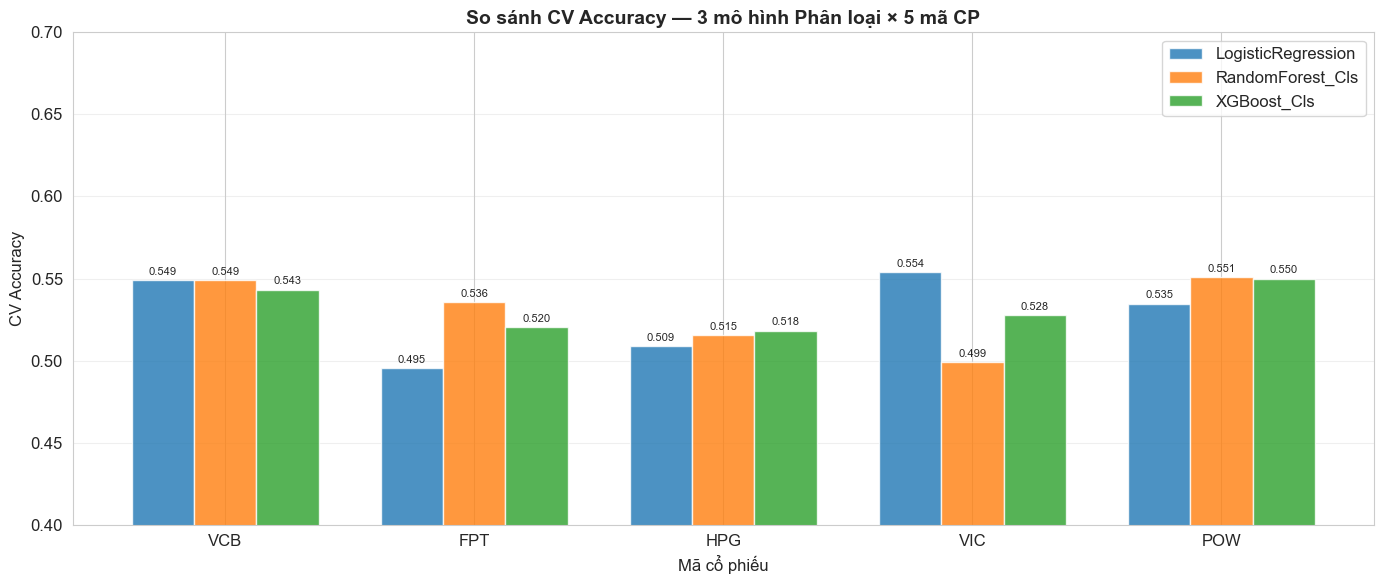

In [16]:
# Biểu đồ so sánh CV Accuracy (Classification)
fig, ax = plt.subplots(figsize=(14, 6))

model_names = list(clf_configs.keys())
x = np.arange(len(STOCK_SYMBOLS))
width = 0.25

for i, model_name in enumerate(model_names):
    scores = [clf_results[s][model_name]['cv_score'] for s in STOCK_SYMBOLS]
    bars = ax.bar(x + i * width, scores, width, label=model_name, alpha=0.8)
    # Hiển thị giá trị trên bar
    for bar, score in zip(bars, scores):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.002,
                f'{score:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Mã cổ phiếu')
ax.set_ylabel('CV Accuracy')
ax.set_title('So sánh CV Accuracy — 3 mô hình Phân loại × 5 mã CP', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(STOCK_SYMBOLS)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(0.4, 0.7)
plt.tight_layout()
plt.show()

## 4.6b. Phân tích ảnh hưởng của Hyperparameter

Phân tích sâu hơn cách từng hyperparameter ảnh hưởng đến hiệu suất mô hình. Điều này giúp hiểu:
- Hyperparameter nào quan trọng nhất?
- Giá trị nào cho kết quả tốt nhất?
- Có dấu hiệu overfitting khi tăng model complexity không?

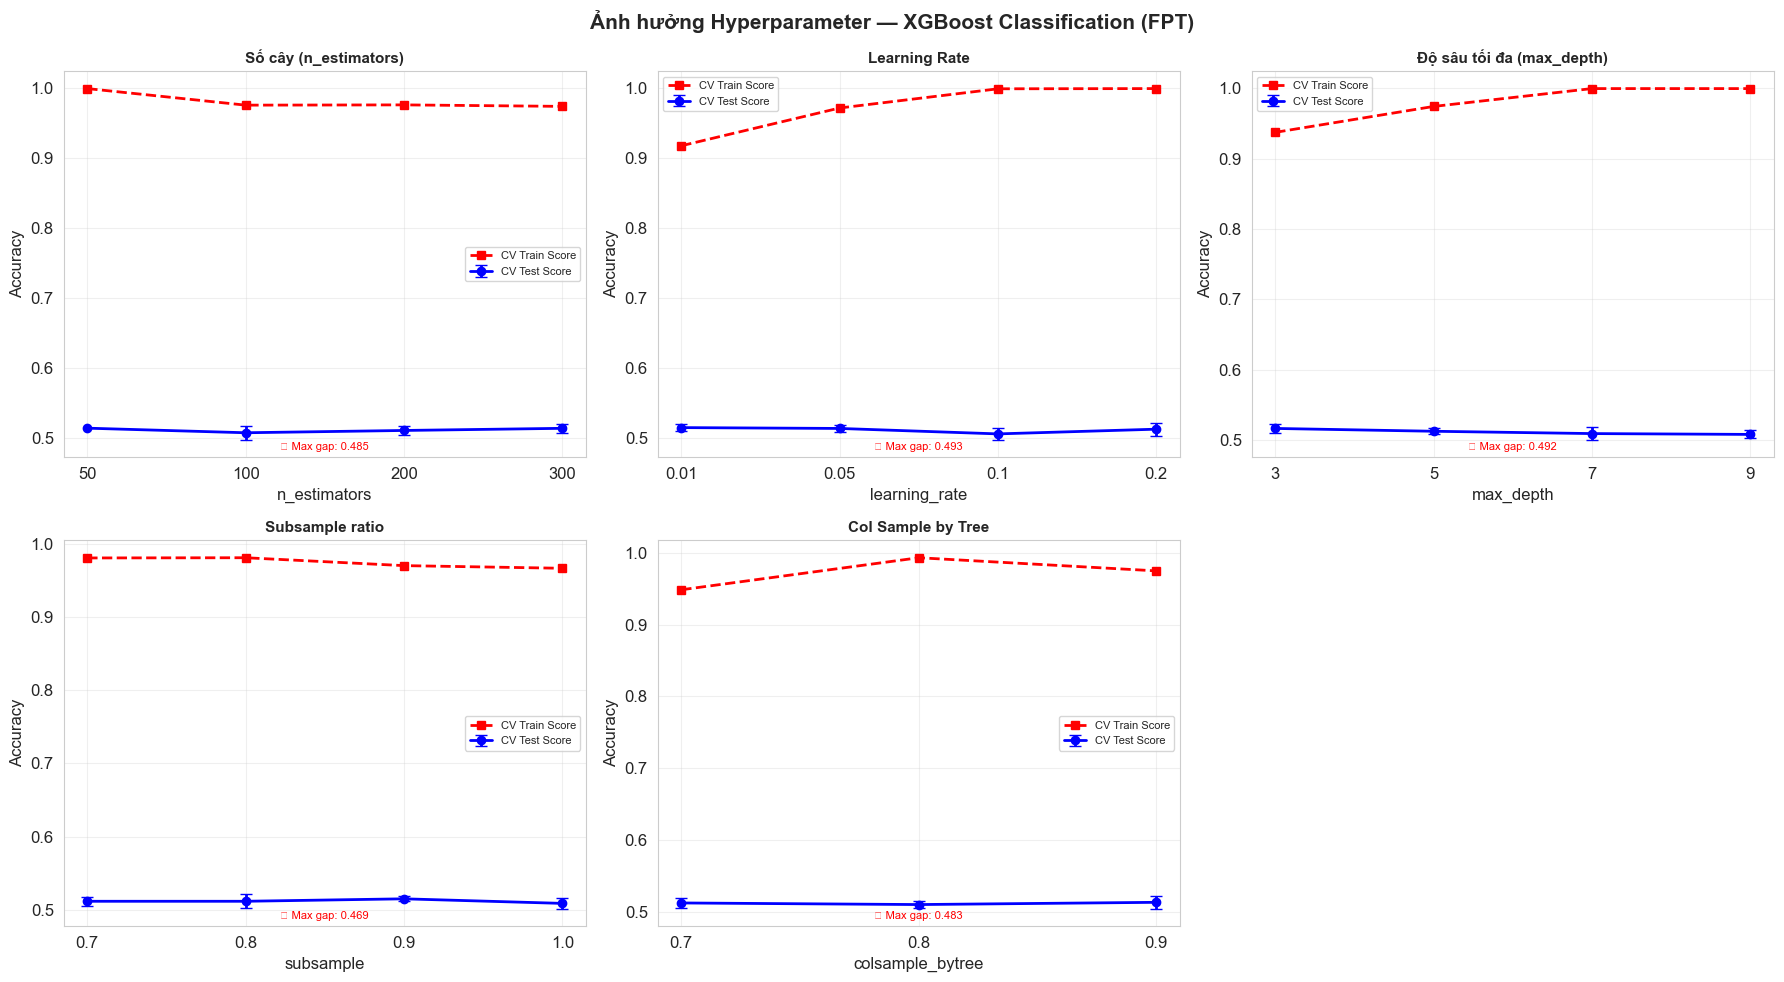

PHÂN TÍCH ẢNH HƯỞNG HYPERPARAMETER — XGBoost (FPT)

Nhận xét từ biểu đồ:
  • Đường Train Score (đỏ) > Test Score (xanh) → mức độ overfitting
  • Gap lớn giữa train/test khi max_depth cao → model quá phức tạp
  • Learning rate thấp (0.01) thường cần nhiều n_estimators hơn
  • Subsample < 1.0 giúp giảm overfitting (regularization effect)


In [17]:
# === PHÂN TÍCH ẢNH HƯỞNG HYPERPARAMETER — XGBoost (Classification) ===
# XGBoost là model phức tạp nhất → phân tích chi tiết nhất

# Lấy 1 mã đại diện (FPT) để phân tích
sample_symbol = 'FPT'
cv_results = pd.DataFrame(clf_results[sample_symbol]['XGBoost_Cls']['cv_results'])

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'Ảnh hưởng Hyperparameter — XGBoost Classification ({sample_symbol})', 
             fontsize=15, fontweight='bold')

# Các hyperparameter cần phân tích
hp_params = [
    ('param_n_estimators', 'n_estimators', 'Số cây (n_estimators)'),
    ('param_learning_rate', 'learning_rate', 'Learning Rate'),
    ('param_max_depth', 'max_depth', 'Độ sâu tối đa (max_depth)'),
    ('param_subsample', 'subsample', 'Subsample ratio'),
    ('param_colsample_bytree', 'colsample_bytree', 'Col Sample by Tree'),
]

for idx, (param_col, param_name, title) in enumerate(hp_params):
    ax = axes.flatten()[idx]
    
    if param_col in cv_results.columns:
        # Nhóm theo giá trị hyperparameter → tính trung bình score
        grouped = cv_results.groupby(param_col).agg({
            'mean_test_score': ['mean', 'std'],
            'mean_train_score': ['mean', 'std']
        }).reset_index()
        
        x_vals = grouped[param_col].astype(str)
        test_mean = grouped[('mean_test_score', 'mean')]
        test_std = grouped[('mean_test_score', 'std')]
        train_mean = grouped[('mean_train_score', 'mean')]
        
        ax.errorbar(x_vals, test_mean, yerr=test_std, marker='o', linewidth=2, 
                     capsize=4, label='CV Test Score', color='blue')
        ax.plot(x_vals, train_mean, marker='s', linewidth=2, 
                label='CV Train Score', color='red', linestyle='--')
        
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel(param_name)
        ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
        
        # Highlight: gap giữa train và test → overfitting
        max_gap = (train_mean - test_mean).max()
        if max_gap > 0.05:
            ax.text(0.5, 0.02, f'⚠ Max gap: {max_gap:.3f}', transform=ax.transAxes,
                    fontsize=8, color='red', ha='center')

# Ẩn subplot thừa
for idx in range(len(hp_params), len(axes.flatten())):
    axes.flatten()[idx].set_visible(False)

plt.tight_layout()
plt.show()

# === PHÂN TÍCH NHẬN XÉT ===
print("=" * 70)
print(f"PHÂN TÍCH ẢNH HƯỞNG HYPERPARAMETER — XGBoost ({sample_symbol})")
print("=" * 70)
print()
print("Nhận xét từ biểu đồ:")
print("  • Đường Train Score (đỏ) > Test Score (xanh) → mức độ overfitting")
print("  • Gap lớn giữa train/test khi max_depth cao → model quá phức tạp")
print("  • Learning rate thấp (0.01) thường cần nhiều n_estimators hơn")
print("  • Subsample < 1.0 giúp giảm overfitting (regularization effect)")

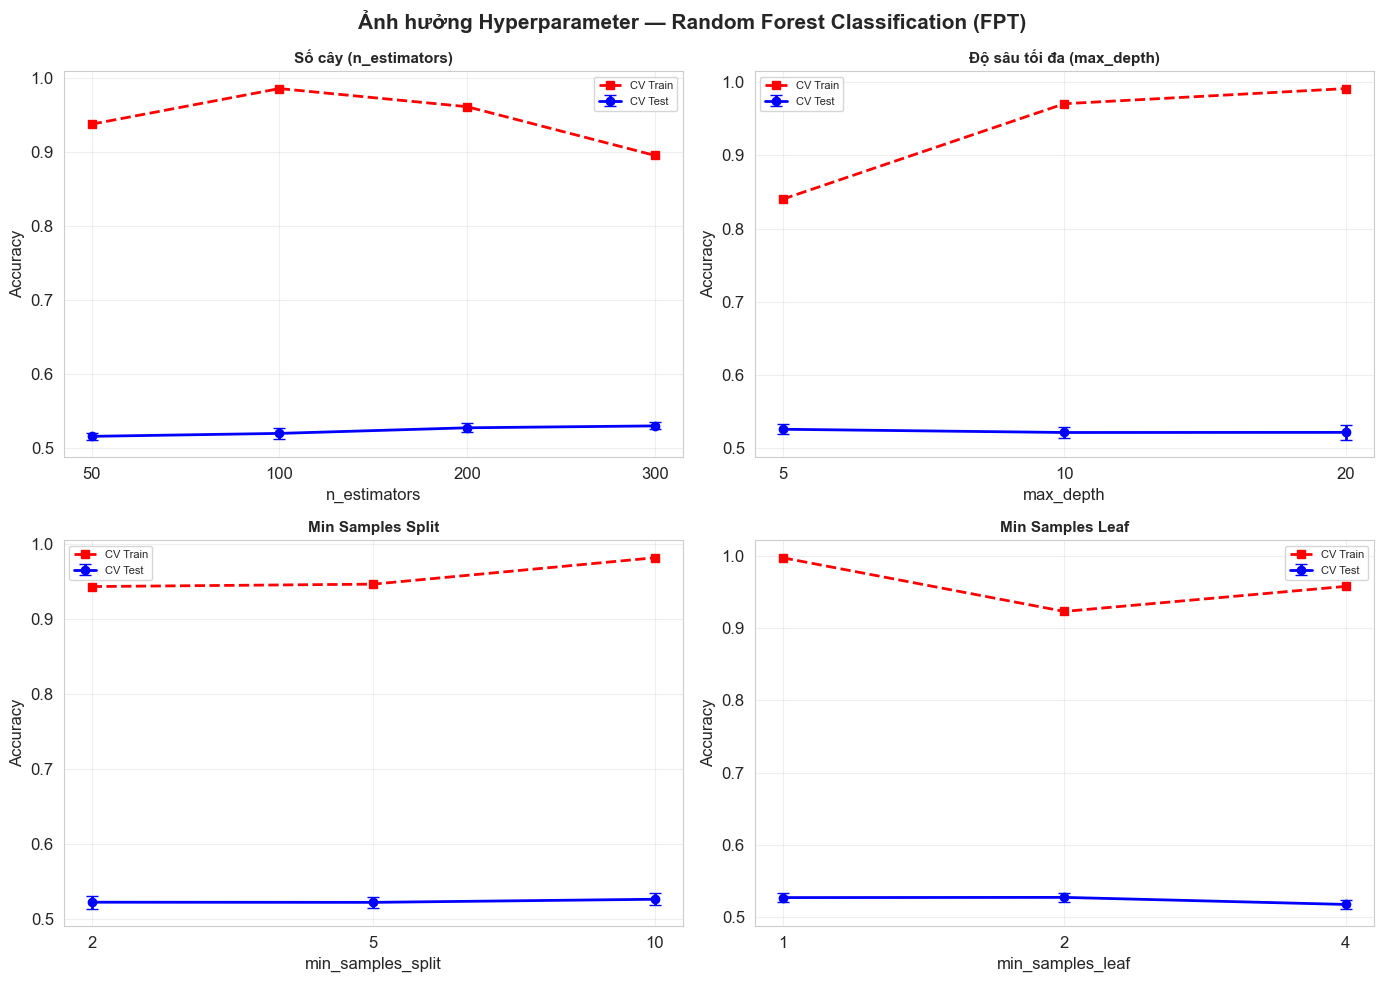


PHÂN TÍCH OVERFITTING — Train Score vs CV Test Score

Mã CP    Model                      Train Score    CV Test      Gap        Đánh giá
--------------------------------------------------------------------------------
VCB      LogisticRegression              0.5888     0.5490   0.0398           ✓ Tốt
VCB      RandomForest_Cls                0.9656     0.5490   0.4166   ⚠ Overfitting
VCB      XGBoost_Cls                     0.9988     0.5433   0.4555   ⚠ Overfitting
FPT      LogisticRegression              0.5633     0.4952   0.0681      ~ Moderate
FPT      RandomForest_Cls                0.9937     0.5356   0.4581   ⚠ Overfitting
FPT      XGBoost_Cls                     0.8532     0.5202   0.3330   ⚠ Overfitting
HPG      LogisticRegression              0.5779     0.5087   0.0692      ~ Moderate
HPG      RandomForest_Cls                0.9585     0.5154   0.4431   ⚠ Overfitting
HPG      XGBoost_Cls                     0.9990     0.5183   0.4807   ⚠ Overfitting
VIC      LogisticRegress

In [18]:
# === PHÂN TÍCH ẢNH HƯỞNG HYPERPARAMETER — Random Forest (Classification) ===
cv_results_rf = pd.DataFrame(clf_results[sample_symbol]['RandomForest_Cls']['cv_results'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Ảnh hưởng Hyperparameter — Random Forest Classification ({sample_symbol})', 
             fontsize=15, fontweight='bold')

rf_params = [
    ('param_n_estimators', 'n_estimators', 'Số cây (n_estimators)'),
    ('param_max_depth', 'max_depth', 'Độ sâu tối đa (max_depth)'),
    ('param_min_samples_split', 'min_samples_split', 'Min Samples Split'),
    ('param_min_samples_leaf', 'min_samples_leaf', 'Min Samples Leaf'),
]

for idx, (param_col, param_name, title) in enumerate(rf_params):
    ax = axes.flatten()[idx]
    
    if param_col in cv_results_rf.columns:
        grouped = cv_results_rf.groupby(param_col).agg({
            'mean_test_score': ['mean', 'std'],
            'mean_train_score': ['mean', 'std']
        }).reset_index()
        
        x_vals = grouped[param_col].astype(str)
        test_mean = grouped[('mean_test_score', 'mean')]
        test_std = grouped[('mean_test_score', 'std')]
        train_mean = grouped[('mean_train_score', 'mean')]
        
        ax.errorbar(x_vals, test_mean, yerr=test_std, marker='o', linewidth=2, 
                     capsize=4, label='CV Test', color='blue')
        ax.plot(x_vals, train_mean, marker='s', linewidth=2, 
                label='CV Train', color='red', linestyle='--')
        
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel(param_name)
        ax.set_ylabel('Accuracy')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# === SO SÁNH TRAIN vs TEST SCORE (Overfitting Analysis) ===
print("\n" + "=" * 70)
print("PHÂN TÍCH OVERFITTING — Train Score vs CV Test Score")
print("=" * 70)
print(f"\n{'Mã CP':8s} {'Model':25s} {'Train Score':>12s} {'CV Test':>10s} {'Gap':>8s} {'Đánh giá':>15s}")
print("-" * 80)

for symbol in STOCK_SYMBOLS:
    for model_name in clf_configs:
        if model_name in clf_results[symbol]:
            cv_res = pd.DataFrame(clf_results[symbol][model_name]['cv_results'])
            best_idx = cv_res['rank_test_score'].idxmin()
            train_score = cv_res.loc[best_idx, 'mean_train_score']
            test_score = cv_res.loc[best_idx, 'mean_test_score']
            gap = train_score - test_score
            
            if gap > 0.1:
                status = "⚠ Overfitting"
            elif gap > 0.05:
                status = "~ Moderate"
            else:
                status = "✓ Tốt"
            
            print(f"{symbol:8s} {model_name:25s} {train_score:12.4f} {test_score:10.4f} {gap:8.4f} {status:>15s}")

## 4.7. Lưu mô hình đã huấn luyện

Lưu tất cả mô hình, scaler, và kết quả vào thư mục `models/` để sử dụng ở Bước 5 (Evaluation) và Bước 6 (Inference).

In [19]:
# Lưu tất cả models và kết quả
print("=" * 70)
print("LƯU MÔ HÌNH VÀ KẾT QUẢ")
print("=" * 70)

for symbol in STOCK_SYMBOLS:
    stock_model_dir = os.path.join(MODELS_DIR, symbol)
    os.makedirs(stock_model_dir, exist_ok=True)
    
    # Lưu scaler
    scaler_path = os.path.join(stock_model_dir, f'{symbol}_feature_scaler.pkl')
    with open(scaler_path, 'wb') as f:
        pickle.dump(clf_results[symbol]['scaler'], f)
    
    # Lưu từng model classification
    for model_name in clf_configs:
        if model_name in clf_results[symbol]:
            model_path = os.path.join(stock_model_dir, f'{symbol}_{model_name}.pkl')
            with open(model_path, 'wb') as f:
                pickle.dump(clf_results[symbol][model_name]['model'], f)
    
    # Lưu từng model regression
    for model_name in reg_configs:
        if model_name in reg_results[symbol]:
            model_path = os.path.join(stock_model_dir, f'{symbol}_{model_name}.pkl')
            with open(model_path, 'wb') as f:
                pickle.dump(reg_results[symbol][model_name]['model'], f)
    
    print(f"  ✓ {symbol}: Đã lưu scaler + {len(clf_configs) + len(reg_configs)} models")

# Lưu toàn bộ kết quả training (metadata, không phải model object)
training_meta = {
    'feature_cols': feature_cols,
    'stock_symbols': STOCK_SYMBOLS,
    'clf_scores': {s: {m: clf_results[s][m]['cv_score'] for m in clf_configs if m in clf_results[s]} for s in STOCK_SYMBOLS},
    'clf_params': {s: {m: clf_results[s][m]['best_params'] for m in clf_configs if m in clf_results[s]} for s in STOCK_SYMBOLS},
    'reg_scores': {s: {m: reg_results[s][m]['cv_rmse'] for m in reg_configs if m in reg_results[s]} for s in STOCK_SYMBOLS},
    'reg_params': {s: {m: reg_results[s][m]['best_params'] for m in reg_configs if m in reg_results[s]} for s in STOCK_SYMBOLS},
}

meta_path = os.path.join(MODELS_DIR, 'training_metadata.pkl')
with open(meta_path, 'wb') as f:
    pickle.dump(training_meta, f)

print(f"\n✓ Training metadata → {meta_path}")
print(f"✓ Tổng cộng: {len(STOCK_SYMBOLS) * (len(clf_configs) + len(reg_configs))} models đã lưu")

LƯU MÔ HÌNH VÀ KẾT QUẢ
  ✓ VCB: Đã lưu scaler + 5 models
  ✓ FPT: Đã lưu scaler + 5 models
  ✓ HPG: Đã lưu scaler + 5 models
  ✓ VIC: Đã lưu scaler + 5 models
  ✓ POW: Đã lưu scaler + 5 models

✓ Training metadata → ..\models\training_metadata.pkl
✓ Tổng cộng: 25 models đã lưu


In [20]:
# Hiển thị bảng Best Hyperparameters cho từng mã (Classification)
print("=" * 90)
print("BEST HYPERPARAMETERS — PHÂN LOẠI")
print("=" * 90)

for symbol in STOCK_SYMBOLS:
    print(f"\n--- {symbol} ---")
    for model_name in clf_configs:
        if model_name in clf_results[symbol]:
            params = clf_results[symbol][model_name]['best_params']
            score = clf_results[symbol][model_name]['cv_score']
            print(f"  {model_name:25s} | Acc={score:.4f} | {params}")

print(f"\n{'='*90}")
print("BEST HYPERPARAMETERS — HỒI QUY")
print("=" * 90)

for symbol in STOCK_SYMBOLS:
    print(f"\n--- {symbol} ---")
    for model_name in reg_configs:
        if model_name in reg_results[symbol]:
            params = reg_results[symbol][model_name]['best_params']
            rmse = reg_results[symbol][model_name]['cv_rmse']
            print(f"  {model_name:25s} | RMSE={rmse:.4f} | {params}")

BEST HYPERPARAMETERS — PHÂN LOẠI

--- VCB ---
  LogisticRegression        | Acc=0.5490 | {'solver': 'lbfgs', 'max_iter': 5000, 'C': 100}
  RandomForest_Cls          | Acc=0.5490 | {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': None}
  XGBoost_Cls               | Acc=0.5433 | {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

--- FPT ---
  LogisticRegression        | Acc=0.4952 | {'solver': 'liblinear', 'max_iter': 3000, 'C': 100}
  RandomForest_Cls          | Acc=0.5356 | {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}
  XGBoost_Cls               | Acc=0.5202 | {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.9}

--- HPG ---
  LogisticRegression        | Acc=0.5087 | {'solver': 'liblinear', 'max_iter': 5000, 'C': 0.01}
  RandomForest_Cls          | Acc=0.5154 | {'n_estimators': 50, 'min_samples_split': 5, 'min_

## Tổng kết Bước 4

### Kết quả đạt được:
- **3 mô hình phân loại** (Logistic Regression, Random Forest, XGBoost) × 5 mã = **15 models**
- **2 mô hình hồi quy** (RF Regressor, XGBoost Regressor) × 5 mã = **10 models**
- Tổng: **25 models** đã huấn luyện và lưu

### Phương pháp:
- ✓ **TimeSeriesSplit(n_splits=5)** — không dùng random split, tránh data leakage
- ✓ **RandomizedSearchCV(n_iter=20)** — tối ưu hyperparameter hiệu quả
- ✓ **StandardScaler** cho Logistic Regression (mô hình tuyến tính cần scaling)
- ✓ Huấn luyện trên **tất cả 5 mã** 
- ✓ Cả **phân loại** và **hồi quy** (bản cũ chỉ có phân loại)

### Cấu trúc output:
```
models/
├── {symbol}/
│   ├── {symbol}_feature_scaler.pkl
│   ├── {symbol}_LogisticRegression.pkl
│   ├── {symbol}_RandomForest_Cls.pkl
│   ├── {symbol}_XGBoost_Cls.pkl
│   ├── {symbol}_RandomForest_Reg.pkl
│   └── {symbol}_XGBoost_Reg.pkl
└── training_metadata.pkl
```

### Bước tiếp theo:
→ **Bước 5: Đánh Giá Mô Hình (Evaluation)** — Đánh giá trên tập test, Confusion Matrix, Feature Importance, Learning Curve